In [ ]:
%load_ext autoreload
%autoreload 2

import functools
import itertools
import math
from math import pi
from multiprocessing.pool import Pool
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import scipy.optimize
import scipy.stats
import tqdm.contrib
import xarray as xr

from fluxoniumcr import DATA_DIR

In [ ]:
from fluxoniumcr.qubits.fluxonium import Fluxonium
from fluxoniumcr.qubits.product_basis import ProductBasis, DressedProductBasis


Q0 = Fluxonium(
    EJ=5.60 * 2*pi,
    EC=1.87 * 2*pi,
    EL=0.56 * 2*pi,
    flux=0.5,
    dim=16,
    cutoff=128,
)

Q1 = Fluxonium(
    EJ=3.52 * 2*pi,
    EC=1.18 * 2*pi,
    EL=0.88 * 2*pi,
    flux=0.5,
    dim=16,
    cutoff=128,
)

JC = 97e-3 * 2*pi

prod_basis = ProductBasis([Q0, Q1])
prod_hamiltonian = (
    + sum(prod_basis.get_operator({i: 'hamiltonian'}) for i in range(2))
    + JC*prod_basis.get_operator(['charge', 'charge'])
)
dressed_basis = DressedProductBasis(
    hamiltonian=prod_hamiltonian,
    bare_basis=prod_basis,
    truncated_dims=(8, 4),
)

def E(*indices):
    index = dressed_basis.flat_index(indices)
    return dressed_basis.eigenvalues[index]

Ω0 = abs((Q0.eigenvalues[1] - Q0.eigenvalues[0])/Q0.get_operator('charge')[0, 1])
Q1_avg_freq = 0.5 * (E(0,1) - E(0,0) + E(1,1) - E(1,0))

In [ ]:
EJ0, EC0, EL0 = Q0.get_parameters(['EJ', 'EC', 'EL'])
EJ1, EC1, EL1 = Q1.get_parameters(['EJ', 'EC', 'EL'])

parent_path = (
    DATA_DIR
    /"time_domain"
    /(
        f"EJc={EJ0/(2*pi):.2f},ECc={EC0/(2*pi):.2f},ELc={EL0/(2*pi):.2f}"
        f",EJt={EJ1/(2*pi):.2f},ECt={EC1/(2*pi):.2f},ELt={EL1/(2*pi):.2f}"
        f",JC={JC/(2*pi):.3f}"
    )
)

In [ ]:
from injector import Injector

from fluxoniumcr.simulation.cnot_solver import (
    CNOTParameters,
    SmoothSquareParameters,
)
from fluxoniumcr.simulation.cnot_solver import CNOTDurationSweep, CNOTSolver
from fluxoniumcr.simulation.cnot_fidelity import (
    calculate_cnot_fidelity,
    calculate_cnot_offset,
    create_cross_resonance_unitary,
)
from fluxoniumcr.simulation.module import SimulationModule
from fluxoniumcr.simulation.operator_resolver import OperatorResolver
from fluxoniumcr.simulation.signals import planck_taper_signal, cosine_taper_signal


root = Injector([
    SimulationModule(
        basis=dressed_basis,
        names=['Q0', 'Q1'],
        dt=0.01,
    ),
])

cnot_solver = root.get(CNOTSolver)
op_resolver = root.get(OperatorResolver)

In [ ]:
pulse_shape = 'planck_taper'
ramp_duration = 20

# ==================================

if pulse_shape == 'planck_taper':
    pulse_factory = planck_taper_signal
elif pulse_shape == 'cosine_taper':
    pulse_factory = cosine_taper_signal
else:
    raise ValueError(f"Unknown shape {pulse_shape!r}")
    
gate_parameters = CNOTParameters(
    pulse_parameters=SmoothSquareParameters(
        total_duration=0.0,
        ramp_duration=ramp_duration,
        amplitude=0.0,
        carrier_freq=Q1_avg_freq,
    ),
    pulse_factory=pulse_factory,
    drive_operator="Q0.charge",
)

In [ ]:
dataset = xr.Dataset()

amplitude_data = Ω0 * np.unique(np.concatenate([
    np.linspace(0, 1.2, 301),
    np.linspace(0.6535, 0.8025, 401),
]))

duration_data = 1e3 * scipy.stats.qmc.Sobol(1, seed=0).random_base2(10).ravel()
duration_data = duration_data[np.argsort(duration_data)]

dataset = xr.Dataset(
    attrs=dict(
        pulse_shape=pulse_shape,
        ramp_duration=ramp_duration,
        carrier_freq=carrier_freq,
    )
)

amplitude_coord = xr.DataArray(
    amplitude_data,
    dims=['amplitude'],
    attrs=dict(
        long_name="Midpoint pulse amplitude",
        plot_unit=Ω0,
        units="Grad/s",
    )
)
amplitude_coord.encoding['scale'] = Ω0

duration_coord = xr.DataArray(
    duration_data,
    dims=['duration'],
    attrs=dict(
        long_name="Plateau duration",
        units="ns",
    )
)

subsys_coord = xr.DataArray(
    ['control', 'target'],
    dims="subsystem",
    attrs=dict(long_name="Hilbert space subsytem name")
)
state_coord = xr.DataArray(
    np.arange(32, dtype=np.uint8),
    dims="state",
    attrs=dict(long_name="Dressed state index")
)
initial_state_coord = xr.DataArray(
    np.arange(32, dtype=np.uint8),
    dims="initial_state",
    attrs=dict(long_name="Dressed state index (initial)")
)
final_state_coord = xr.DataArray(
    np.arange(32, dtype=np.uint8),
    dims="final_state",
    attrs=dict(long_name="Dressed state index (final)")
)
qudit_labels = []
for i in range(dressed_basis.truncated_dims[0]):
    for j in range(dressed_basis.truncated_dims[1]):
        qudit_labels.append((i, j))

dataset['state_label'] = xr.DataArray(
    np.array(qudit_labels, np.uint8),
    coords=[state_coord, subsys_coord],
    attrs=dict(
        long_name="Maximum overlap bare state label",
    )
)

dataset['drive_operator'] = xr.DataArray(
    op_resolver.resolve(gate_parameters.drive_operator),
    coords=[final_state_coord, initial_state_coord],
    attrs=dict(
        long_name="Control fluxonium charge operator",
    )
)

dataset['hamiltonian'] = xr.DataArray(
    np.diag(op_resolver.H0),
    coords=[state_coord],
    attrs=dict(
        long_name="Eigenvalues of the time-independent Hamiltonian",
        units="Grad/s"
    )
)
dataset['unitary'] = xr.DataArray(
    data=np.complex64(np.nan + 1j*np.nan),
    coords=[
        amplitude_coord,
        duration_coord,
        final_state_coord,
        initial_state_coord,
    ],
    attrs=dict(
        long_name="Unitary",
    )
)
dataset['average_transition_probability'] = xr.DataArray(
    data=np.float32(np.nan),
    coords=[
        amplitude_coord,
        final_state_coord,
        initial_state_coord,
    ],
    attrs=dict(
        long_name="Average transition probability",
    )
)

def save_dataset(dataset):
    dataset.to_netcdf(parent_path/"random_duration.hdf5", engine="h5netcdf", invalid_netcdf=True)

In [ ]:
def doit(amp, duration_data):
    p = gate_parameters.copy()
    p.pulse_parameters['amplitude'] = amp
    sweeper = cnot_solver.create_duration_sweep(p)
    unitary_data = []
    for dur in duration_data:
        U = sweeper.solve(dur, return_unitary=True)
        unitary_data.append(U)
    return unitary_data


last_save = time.time()

with Pool(processes=4) as pool:
    for amp, unitary_data in tqdm.contrib.tzip(
            dataset.amplitude.data,
            pool.imap(
                functools.partial(
                    doit,
                    duration_data=dataset.duration.data
                ),
                dataset.amplitude.data
            ),
    ):
        ds = dataset.loc[dict(amplitude=amp)]
        ds.unitary[:] = unitary_data
        
        if (now := time.time() - last_save > 300:
            save_dataset(dataset)
            last_save = now

In [ ]:
for amp in tqdm.tqdm(dataset.amplitude.data):
    ds = dataset.loc[dict(amplitude=amp)]
    p = gate_parameters.copy()
    p.pulse_parameters['amplitude'] = amp
    P = cnot_solver.calculate_transition_probabilities(p)
    ds.average_transition_probability[:] = P

In [ ]:
save_dataset(dataset)

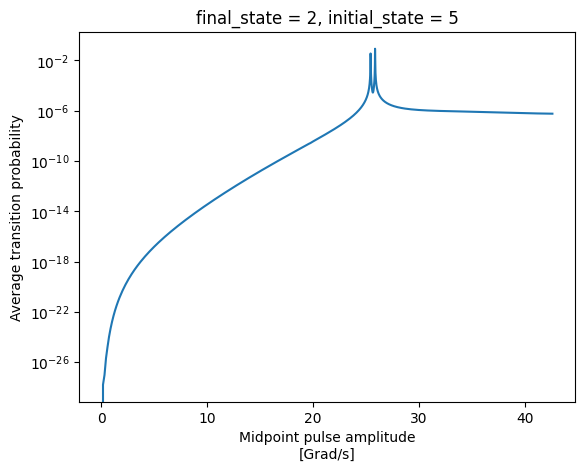

In [11]:
dataset.average_transition_probability.sel(final_state=2, initial_state=5).plot()
plt.yscale('log')